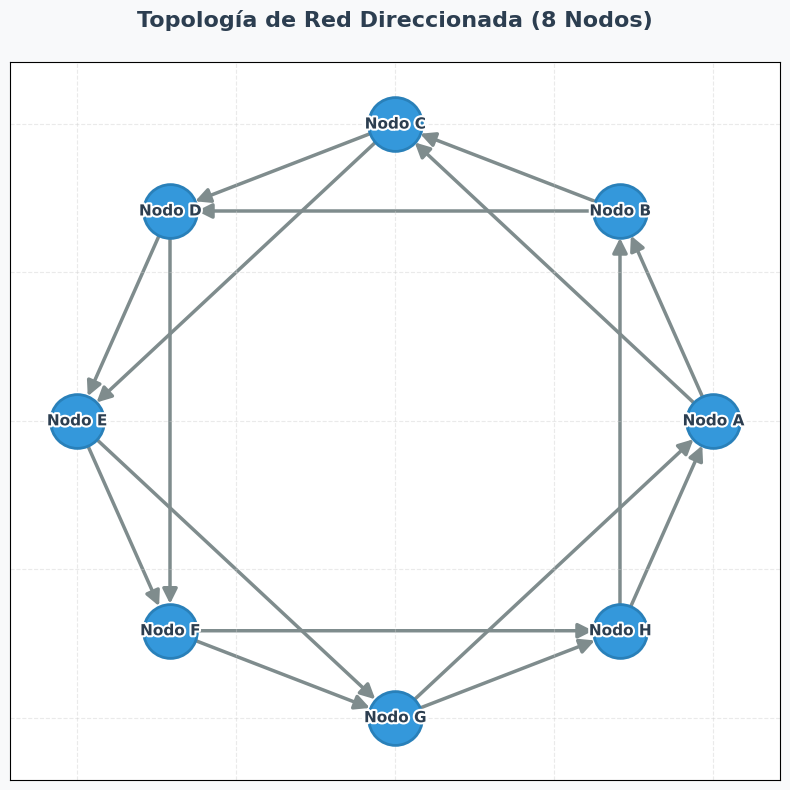

In [3]:
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import networkx as nx


def crear_red_anillo(cantidad_nodos=8):
    """Crea un grafo dirigido en topología de anillo (cada nodo se comunica con 2)."""
    G = nx.DiGraph()

    # Generamos nombres de nodos legibles (Nodo A, Nodo B, etc.)
    nodos = [f"Nodo {chr(65 + i)}" for i in range(cantidad_nodos)]
    G.add_nodes_from(nodos)

    # Creamos las conexiones dirigidas en anillo con dos flechas salientes por nodo
    conexiones = []
    for i in range(cantidad_nodos):
        conexiones.append((nodos[i], nodos[(i + 1) % cantidad_nodos])) # Conecta con el siguiente nodo
        conexiones.append((nodos[i], nodos[(i + 2) % cantidad_nodos])) # Conecta con el segundo siguiente nodo

    G.add_edges_from(conexiones)

    return G


def graficar_red(G):
    """Renderiza la topología de red con un diseño limpio y profesional,

    optimizando la legibilidad de las etiquetas.
    """
    # Configuración del lienzo
    plt.figure(figsize=(8, 8), facecolor="#f8f9fa")
    plt.title(
        "Topología de Red Direccionada (8 Nodos)",
        fontsize=16,
        fontweight="bold",
        pad=25,
        color="#2c3e50",
    )

    # Distribución circular perfecta
    pos = nx.circular_layout(G)

    # 1. Dibujar los nodos con estilo moderno
    nx.draw_networkx_nodes(
        G, pos, node_color="#3498db", node_size=1500, edgecolors="#2980b9", linewidths=2
    )

    # 2. Dibujar las flechas de comunicación bien definidas
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="#7f8c8d",
        width=2.5,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        node_size=1500,
    )

    # 3. Dibujar las etiquetas de los nodos (Texto oscuro con contorno blanco)
    labels = {node: str(node) for node in G.nodes()}

    label_options = {
        "labels": labels,
        "font_size": 11,
        "font_weight": "bold",
        "font_color": "#2c3e50",
        "horizontalalignment": "center",
        "verticalalignment": "center",
    }

    label_collection = nx.draw_networkx_labels(G, pos, **label_options)

    # Aplicamos el efecto de contorno (halo) blanco a cada letra para despegarlo del fondo
    for _, text_obj in label_collection.items():
        text_obj.set_path_effects([
            path_effects.Stroke(linewidth=3, foreground="white"),
            path_effects.Normal()
        ])

    # 4. Detalles finales de presentación (Simulación de plano técnico)
    plt.gca().set_facecolor("#ffffff")
    plt.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
    plt.axis("on")

    # Ocultamos los números de los ejes para que quede limpio
    plt.tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

    plt.tight_layout()
    plt.show()


# --- Ejecución del Programa Principal ---
if __name__ == "__main__":
    # Creamos la topología con la restricción pedida
    red_comunicacion = crear_red_anillo(cantidad_nodos=8)

    # Graficamos el resultado final para la presentación
    graficar_red(red_comunicacion)